# Whale location regression

Predict `(decimalLatitude, decimalLongitude)` of a whale sighting from month + sea conditions + species + Open-Meteo archive weather. Dataset: Futurismo Azores whale-watching, 20082018 (GBIF DwC-A).

## 1. Load & merge data

- `occurrence.txt`  one row per sighting, has `eventID` and `scientificName`
- `event.txt`  has `decimalLatitude`, `decimalLongitude`, `eventDate`
- `extendedmeasurementorfact.txt`  long-format observations (Beaufort, visibility)

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA = Path(r'C:\Users\minju\Desktop\CSProjects\whaleTracker\predictionModel\dataset2\gbif')

occ = pd.read_csv(DATA / 'occurrence.txt', sep='\t', low_memory=False)
evt = pd.read_csv(DATA / 'event.txt',      sep='\t', low_memory=False)
emof = pd.read_csv(DATA / 'extendedmeasurementorfact.txt', sep='\t', low_memory=False)

# Pivot emof long  wide
wanted = ['Beaufort wind force', 'visibility']
emof_wide = (emof[emof['measurementType'].isin(wanted)]
             .pivot_table(index='id', columns='measurementType',
                          values='measurementValue', aggfunc='first')
             .reset_index()
             .rename(columns={'id': 'eventID',
                              'Beaufort wind force': 'beaufort',
                              'visibility': 'visibility_bin'}))

df = (occ[['eventID', 'scientificName']]
      .merge(evt[['eventID', 'decimalLatitude', 'decimalLongitude', 'eventDate']], on='eventID', how='left')
      .merge(emof_wide, on='eventID', how='left'))
print(df.shape)
df.head()

(20413, 7)


,eventID,scientificName,decimalLatitude,decimalLongitude,eventDate,beaufort,visibility_bin
0,FUT_SM0818_cruise0001:encounter00001,Tursiops truncatus,37.690183,-25.486567,2008-05-03T10:00/2008-05-03T10:30,5,3
1,FUT_SM0818_cruise0001:encounter00002,Delphinus delphis,37.633433,-25.417500,2008-05-03T10:50/2008-05-03T11:10,5,5
2,FUT_SM0818_cruise0002:encounter00003,Delphinus delphis,37.716950,-25.633417,2008-05-03T13:20/2008-05-03T13:40,4,15
3,FUT_SM0818_cruise0002:encounter00004,Tursiops truncatus,37.668217,-25.573200,2008-05-03T14:00/2008-05-03T14:20,4,20
4,FUT_SM0818_cruise0003:encounter00005,Delphinus delphis,37.668217,-25.573200,2008-05-06/2008-05-06,1,25


## 2. Feature engineering

Parse date  month; visibility bins  numeric midpoint; beaufort  numeric.

In [13]:
df['event_start'] = pd.to_datetime(df['eventDate'].str.split('/').str[0], errors='coerce')
df['month'] = df['event_start'].dt.month

vis_map = {
    '< 1':     0.5,
    '1  5':   3.0, '1 - 5':  3.0,
    '5  10':  7.5, '5 - 10': 7.5,
    '10  15': 12.5, '10 - 15': 12.5,
    '> 15':    20.0,
}
df['visibility_km'] = df['visibility_bin'].map(vis_map)
df['beaufort'] = pd.to_numeric(df['beaufort'], errors='coerce')

core = ['decimalLatitude', 'decimalLongitude', 'event_start', 'month',
        'beaufort', 'visibility_km', 'scientificName']
df_model = df.dropna(subset=core).copy()
print('rows kept:', len(df_model), '/', len(df))

rows kept: 13153 / 20413


## 3. Fetch hourly weather (Open-Meteo archive)

One archive call at the dataset centerpoint covers the full date range (all sightings are within a ~0.5° box smaller than Open-Meteo's grid cell).

In [14]:
import requests

lat_c = float(df_model['decimalLatitude'].mean())
lon_c = float(df_model['decimalLongitude'].mean())
d_min = df_model['event_start'].dt.date.min().isoformat()
d_max = df_model['event_start'].dt.date.max().isoformat()
print(f'fetching ({lat_c:.3f}, {lon_c:.3f}) from {d_min} to {d_max}')

weather_vars = ['temperature_2m', 'surface_pressure', 'pressure_msl',
                'dew_point_2m', 'wind_speed_10m', 'relative_humidity_2m']

resp = requests.get(
    'https://archive-api.open-meteo.com/v1/archive',
    params={
        'latitude': lat_c, 'longitude': lon_c,
        'start_date': d_min, 'end_date': d_max,
        'hourly': ','.join(weather_vars),
    },
    timeout=120,
)
resp.raise_for_status()
data = resp.json()['hourly']

weather = pd.DataFrame(data)
weather['time'] = pd.to_datetime(weather['time'])

df_model['event_hour'] = df_model['event_start'].dt.floor('h')
df_model = df_model.merge(weather, left_on='event_hour', right_on='time', how='left')
df_model = df_model.dropna(subset=weather_vars).copy()
print('rows after weather merge:', len(df_model))
weather_cols = weather_vars


fetching (37.659, -25.606) from 2009-09-18 to 2018-12-27
rows after weather merge: 13153


## 4. Train regression model

RandomForestRegressor handles the two-output (lat, lon) target natively. Features: month, in-situ observations (beaufort, visibility), API weather, and species (one-hot).

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

feature_cols = ['month', 'beaufort', 'visibility_km',
                'temperature_2m', 'surface_pressure', 'pressure_msl',
                'dew_point_2m', 'wind_speed_10m', 'relative_humidity_2m']
X = pd.concat([
    df_model[feature_cols].reset_index(drop=True),
    pd.get_dummies(df_model['scientificName'], prefix='sp').reset_index(drop=True),
], axis=1)
y = df_model[['decimalLatitude', 'decimalLongitude']].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(
    n_estimators=300, max_depth=None, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

## 5. Evaluate

MAE in degrees + great-circle distance (km) between predicted and actual point. Baseline: always predict the training-set mean.

In [16]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

mae_lat = mean_absolute_error(y_test['decimalLatitude'],  pred[:, 0])
mae_lon = mean_absolute_error(y_test['decimalLongitude'], pred[:, 1])
r2_lat  = r2_score(y_test['decimalLatitude'],  pred[:, 0])
r2_lon  = r2_score(y_test['decimalLongitude'], pred[:, 1])

dist_km = haversine_km(y_test['decimalLatitude'].values, y_test['decimalLongitude'].values,
                       pred[:, 0], pred[:, 1])

# baseline: predict mean
mean_lat, mean_lon = y_train['decimalLatitude'].mean(), y_train['decimalLongitude'].mean()
base_km = haversine_km(y_test['decimalLatitude'].values, y_test['decimalLongitude'].values,
                       np.full(len(y_test), mean_lat), np.full(len(y_test), mean_lon))

print(f'MAE lat: {mae_lat:.4f}°   MAE lon: {mae_lon:.4f}°')
print(f'R²  lat: {r2_lat:.3f}     R²  lon: {r2_lon:.3f}')
print(f'mean haversine: {dist_km.mean():.2f} km   median: {np.median(dist_km):.2f} km')
print(f'baseline (predict mean) haversine: {base_km.mean():.2f} km')

MAE lat: 0.0238°   MAE lon: 0.0595°
R²  lat: 0.717     R²  lon: 0.725
mean haversine: 6.33 km   median: 4.18 km
baseline (predict mean) haversine: 14.99 km


## 6. Visualize

Top 15 features:
wind_speed_10m               0.183708
dew_point_2m                 0.143361
temperature_2m               0.136874
relative_humidity_2m         0.111446
surface_pressure             0.103379
pressure_msl                 0.102685
month                        0.080062
beaufort                     0.055025
sp_Physeter macrocephalus    0.022723
sp_Globicephala              0.006998
sp_Delphinus delphis         0.005393
sp_Balaenoptera physalus     0.005340
sp_Balaenoptera borealis     0.004969
sp_Tursiops truncatus        0.004616
sp_Grampus griseus           0.004589
dtype: float64


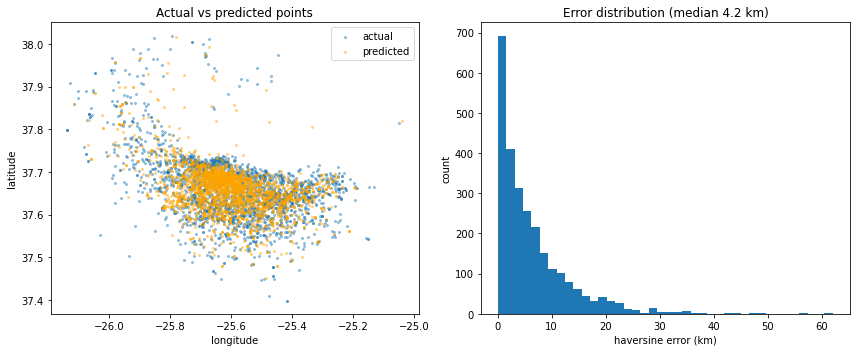

In [17]:
import matplotlib.pyplot as plt

imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Top 15 features:')
print(imp.head(15))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test['decimalLongitude'], y_test['decimalLatitude'], s=4, alpha=0.4, label='actual')
axes[0].scatter(pred[:, 1], pred[:, 0], s=4, alpha=0.4, label='predicted', color='orange')
axes[0].set_xlabel('longitude'); axes[0].set_ylabel('latitude')
axes[0].set_title('Actual vs predicted points'); axes[0].legend()

axes[1].hist(dist_km, bins=40)
axes[1].set_xlabel('haversine error (km)'); axes[1].set_ylabel('count')
axes[1].set_title(f'Error distribution (median {np.median(dist_km):.1f} km)')
plt.tight_layout()
plt.show()